In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [2]:
TRAIN_CSV = "../data/kaggle/fashion-mnist_train.csv"
TEST_CSV = "../data/kaggle/fashion-mnist_test.csv"

BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 50
VALID_RATIO = 0.2 
RANDOM_SEED = 42

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
class FashionMNISTCSVDataset(Dataset):
    def __init__(self, csv_file):
        df = pd.read_csv(csv_file)

        self.labels = df.iloc[:, 0].to_numpy(dtype=np.int64)
        self.images = df.iloc[:, 1:].to_numpy(dtype=np.float32) / 255.0  
        self.images = self.images.reshape(-1, 1, 28, 28) 

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = torch.from_numpy(self.images[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

In [4]:
test_dataset = FashionMNISTCSVDataset(TEST_CSV)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

In [5]:
class FashionCNNFlexible(nn.Module):
    def __init__(
        self,
        conv_channels=[32, 64],
        kernel_size=3,
        pool_type="max",
        activation="relu",
        dropout=0.3,
        use_batchnorm=False,
        num_classes=10
    ):
        super().__init__()

        layers = []
        in_channels = 1
        current_size = 28  
        
        def get_activation():
            if activation.lower() == "relu":
                return nn.ReLU()
            elif activation.lower() == "gelu":
                return nn.GELU()
            else:
                raise ValueError(f"Unsupported activation: {activation}")

        def get_pool():
            if pool_type.lower() == "max":
                return nn.MaxPool2d(kernel_size=2, stride=2)
            elif pool_type.lower() == "avg":
                return nn.AvgPool2d(kernel_size=2, stride=2)
            else:
                raise ValueError(f"Unsupported pool type: {pool_type}")

        padding = kernel_size // 2  # keep spatial size same after conv

        for out_channels in conv_channels:
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding))
            # (current_size + 2*padding - kernel_size)/stride + 1 = input, so padding = kernel_size // 2 keeps the size same
            
            if use_batchnorm:
                layers.append(nn.BatchNorm2d(out_channels))
            
            layers.append(get_activation())
            layers.append(get_pool())

            in_channels = out_channels
            current_size = current_size // 2  # after 2x2 pooling

        self.features = nn.Sequential(*layers)

        flattened_dim = conv_channels[-1] * current_size * current_size

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_dim, 128),
            get_activation(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [6]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad(): # tells PyTorch not to calculate gradients, which saves memory and computations during evaluation
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy()) # This saves all predictions and actual labels across all batches
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, np.array(all_preds), np.array(all_labels)

In [ ]:
# Model configuration 
Version = 4
fold = 4
model_config = {
    "conv_channels": [32, 64],
    "kernel_size": 3,
    "pool_type": "avg",
    "activation": "relu",
    "dropout": 0.3,
    "use_batchnorm": False
}

# Setup device and model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FashionCNNFlexible(**model_config).to(device)

print("-" * 30)

criterion = nn.CrossEntropyLoss()


model_path = f"saved_models_kfold/V{Version}_AvgPool_fold{fold}_best_loss.pth"
    
    
model.load_state_dict(torch.load(model_path, map_location=device))
test_loss, test_acc, y_pred, y_true = evaluate(model, test_loader, criterion, device)
    
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4%}")

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))


Starting Evaluation for 5 Folds...
------------------------------


/Users/jiacheng/Documents/NUS_Course/CS3244/group_project/cnn_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Test Loss: 0.2085
Test Accuracy: 92.3800%
              precision    recall  f1-score   support

 T-shirt/top     0.8739    0.8660    0.8699      1000
     Trouser     0.9890    0.9880    0.9885      1000
    Pullover     0.8795    0.8830    0.8812      1000
       Dress     0.9238    0.9340    0.9289      1000
        Coat     0.8836    0.8880    0.8858      1000
      Sandal     0.9949    0.9740    0.9843      1000
       Shirt     0.7811    0.7780    0.7796      1000
     Sneaker     0.9510    0.9710    0.9609      1000
         Bag     0.9939    0.9850    0.9895      1000
  Ankle boot     0.9681    0.9710    0.9695      1000

    accuracy                         0.9238     10000
   macro avg     0.9239    0.9238    0.9238     10000
weighted avg     0.9239    0.9238    0.9238     10000



In [8]:
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))


              precision    recall  f1-score   support

 T-shirt/top     0.8739    0.8660    0.8699      1000
     Trouser     0.9890    0.9880    0.9885      1000
    Pullover     0.8795    0.8830    0.8812      1000
       Dress     0.9238    0.9340    0.9289      1000
        Coat     0.8836    0.8880    0.8858      1000
      Sandal     0.9949    0.9740    0.9843      1000
       Shirt     0.7811    0.7780    0.7796      1000
     Sneaker     0.9510    0.9710    0.9609      1000
         Bag     0.9939    0.9850    0.9895      1000
  Ankle boot     0.9681    0.9710    0.9695      1000

    accuracy                         0.9238     10000
   macro avg     0.9239    0.9238    0.9238     10000
weighted avg     0.9239    0.9238    0.9238     10000



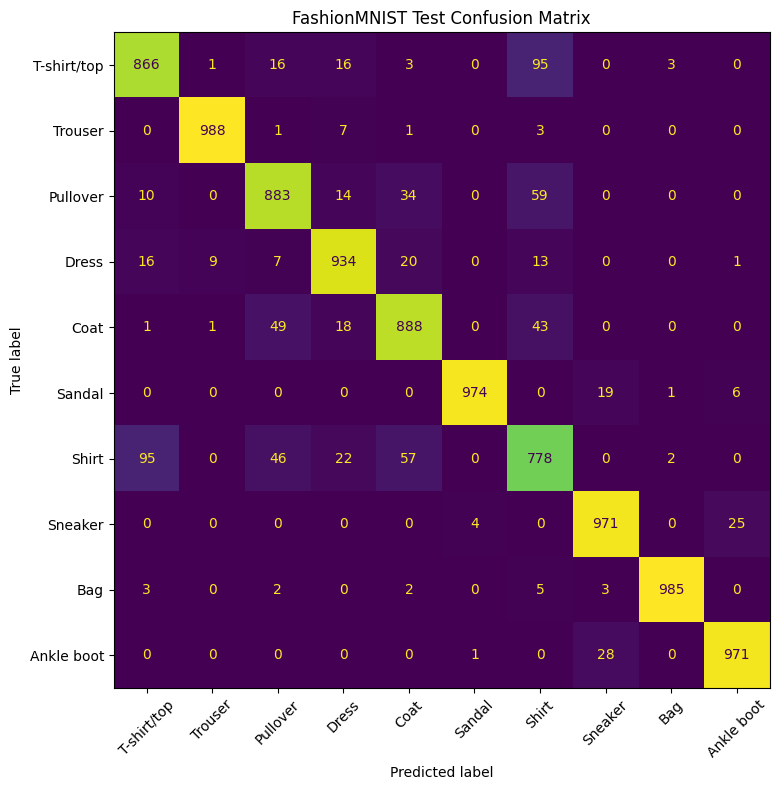

In [9]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(
    ax=ax,
    xticks_rotation=45,
    colorbar=False,
)
plt.title("FashionMNIST Test Confusion Matrix")
plt.tight_layout()
plt.show()
